# Experiment Claims

**Source file:** `prior_manipulation_results.pkl` (generated by `prior_sweep.py`)

---

## Claim 9 (Prior Generalization): The transformer generalizes the Laplace result to arbitrary Beta priors.

A transformer trained under Beta(α, β) converges toward the Bayes-optimal estimator for that prior. At Beta(1,1), the transformer, Laplace, and the oracle all align : Laplace is the Bayes-optimal here by definition. At Beta(0.5,0.5), l=10: transformer 0.7147, Laplace 0.7234, oracle 0.7107. The transformer sits slightly above the oracle but clearly below Laplace : it has adapted to the prior shape.

Mismatched prior conditions (train on one alpha, test on another) show partial transfer: the transformer stays below Laplace at all l but does not reach the oracle floor. This extends Claim 1 from a uniform prior to the full Beta family.

*Key numbers:* Beta(0.5,0.5), l=10: transformer 0.7147, oracle 0.7107, Laplace 0.7234. Beta(5,5), l=10: transformer 0.9831, oracle 0.9839, Laplace 1.0199.


# In-Context Bayesian Estimation: Plots

In [22]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from scipy.stats import beta as beta_dist
from scipy.integrate import quad
import os

with open('./experiments/prior_manipulation_results.pkl', 'rb') as f:
    all_results = pickle.load(f)

PRIORS   = [(1.0,1.0),(0.5,0.5),(5.0,5.0),(5.0,2.0),(2.0,5.0)]
N_VALUES = sorted(all_results[PRIORS[0]].keys())

# ── Palette ──────────────────────────────────────────────────────────────────
C_TRANSFORMER = '#002d4d'
C_BAYES       = '#177F6B'
C_CTW         = '#9C4732'
C_ENTROPY     = '#888888'
BG   = '#FFFFFF'
GRID = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
})

PRIOR_LABELS = {
    (1.0,1.0): 'Beta(1,1)\nuniform (control)',
    (0.5,0.5): 'Beta(0.5,0.5)\nbimodal',
    (5.0,5.0): 'Beta(5,5)\nconcentrated at 0.5',
    (5.0,2.0): 'Beta(5,2)\nskewed high',
    (2.0,5.0): 'Beta(2,5)\nskewed low',
}

os.makedirs('figures', exist_ok=True)

# ── Helper: extract mean/std safely ──────────────────────────────────────────
def get_mean(s, N, key):
    v = s[N][key]
    return v['mean'] if isinstance(v, dict) else v

def get_std(s, N, key):
    v = s[N][key]
    return v['std'] if isinstance(v, dict) else 0.0

def get_ci(s, N, key):
    v = s[N][key]
    return v['ci'] if isinstance(v, dict) and 'ci' in v else 0.0
print('Setup done. N values:', N_VALUES)

FileNotFoundError: [Errno 2] No such file or directory: './experiments/prior_manipulation_results.pkl'

## Entropy floors

In [ ]:
def expected_entropy(alpha, b):
    """E_p[H(Bernoulli(p))] where p ~ Beta(alpha, b), computed numerically."""
    def integrand(p):
        if p <= 0 or p >= 1:
            return 0.0
        h = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
        return beta_dist.pdf(p, alpha, b) * h
    val, _ = quad(integrand, 0, 1, limit=200)
    return val

ENTROPY_FLOOR = {(a, b): expected_entropy(a, b) for (a, b) in PRIORS}

print('Entropy floors:')
for k, v in ENTROPY_FLOOR.items():
    print(f'  Beta{k}: {v:.4f} bits/symbol')

Entropy floors:
  Beta(1.0, 1.0): 0.7213 bits/symbol
  Beta(0.5, 0.5): 0.5573 bits/symbol
  Beta(5.0, 5.0): 0.9315 bits/symbol
  Beta(5.0, 2.0): 0.7694 bits/symbol
  Beta(2.0, 5.0): 0.7694 bits/symbol


## Fig 1: BPS vs N 

Transformer tracks Bayes-optimal. CTW lags at small N due to warmup.

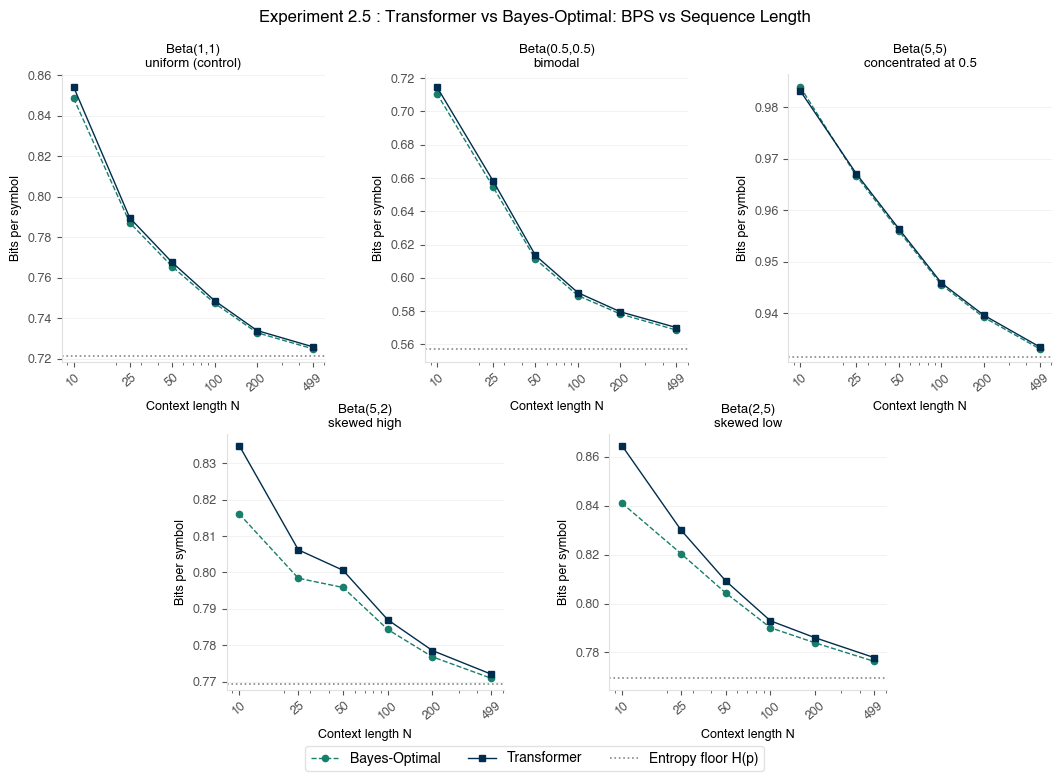

Saved figures/fig1_bps_overview


In [ ]:
def make_bps_grid(save_stem):
    fig = plt.figure(figsize=(11, 8))
    fig.patch.set_facecolor(BG)

    gs_top = gridspec.GridSpec(1, 3, top=0.89, bottom=0.53, left=0.07, right=0.97, wspace=0.38)
    gs_bot = gridspec.GridSpec(1, 2, top=0.44, bottom=0.12, left=0.22, right=0.82, wspace=0.38)
    axes_top = [fig.add_subplot(gs_top[0, i]) for i in range(3)]
    axes_bot = [fig.add_subplot(gs_bot[0, i]) for i in range(2)]
    all_axes = axes_top + axes_bot

    for ax, (alpha, beta) in zip(all_axes, PRIORS):
        s  = all_results[(alpha, beta)]
        ns = np.array(N_VALUES)

        for key, color, ls, marker, lbl in [
            ('bayes_optimal', C_BAYES,       '--', 'o', 'Bayes-Optimal'),
            ('transformer',   C_TRANSFORMER, '-',  's', 'Transformer'),
        ]:
            means = np.array([get_mean(s, N, key) for N in N_VALUES])
            stds  = np.array([get_std(s,  N, key) for N in N_VALUES])
            ax.plot(ns, means, color=color, lw=1.0, ls=ls,
                    marker=marker, ms=4.5, label=lbl, zorder=3)
            #ax.fill_between(ns, means - stds, means + stds,
                            #color=color, alpha=0.12, zorder=2)

        ax.axhline(ENTROPY_FLOOR[(alpha, beta)], color=C_ENTROPY,
                   lw=1.2, ls=':', label='Entropy floor H(p)', zorder=1)

        ax.set_xscale('log')
        ax.set_xticks(N_VALUES)
        ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
        ax.tick_params(axis='x', rotation=40)
        ax.set_xlabel('Context length N', fontsize=9)
        ax.set_ylabel('Bits per symbol', fontsize=9)
        ax.set_title(PRIOR_LABELS[(alpha, beta)], fontsize=9.5, pad=5)
        ax.grid(True, axis='y', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    handles, labels = all_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)

    fig.suptitle('Experiment 2.5 : Transformer vs Bayes-Optimal: BPS vs Sequence Length',
                 fontsize=12, fontweight='bold', y=0.97)

    plt.savefig(f'figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/{save_stem}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/{save_stem}')

make_bps_grid('fig1_bps_overview')

## Fig 2: Redundancy gap to Bayes-Optimal 

The key figure. Transformer hugs zero. CTW decays from above.

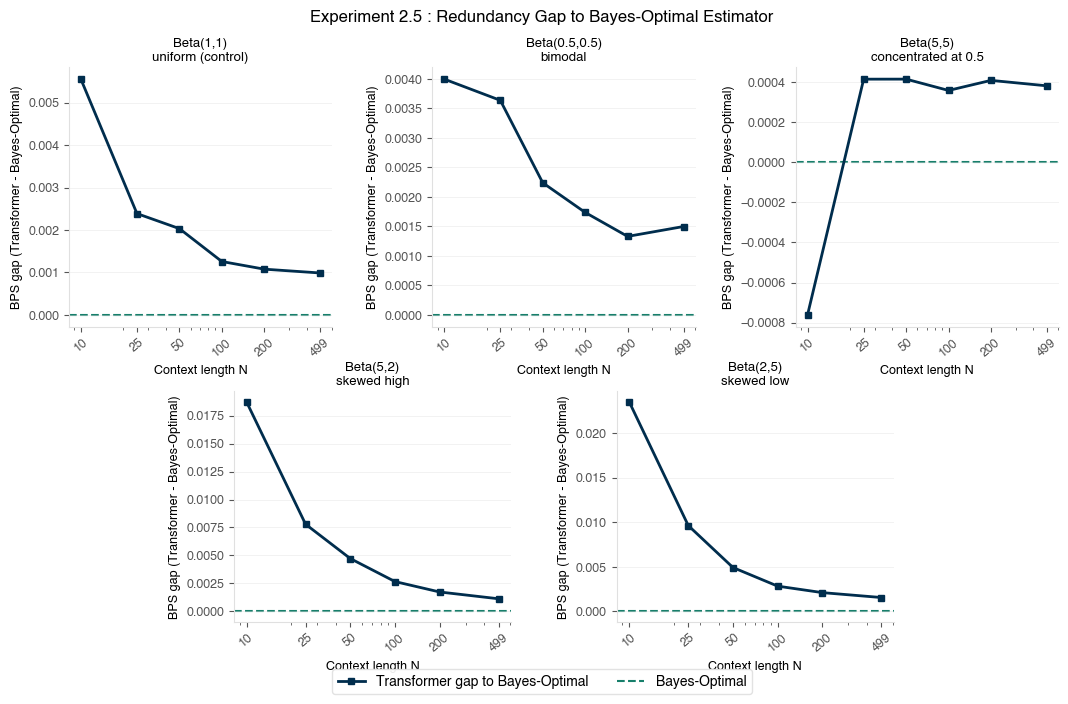

Saved figures/fig2_gap_overview


In [ ]:

def make_gap_grid(save_stem):
    fig = plt.figure(figsize=(11, 7.2))
    fig.patch.set_facecolor(BG)

    gs_top = gridspec.GridSpec(1, 3, top=0.89, bottom=0.53, left=0.07, right=0.97, wspace=0.38)
    gs_bot = gridspec.GridSpec(1, 2, top=0.44, bottom=0.12, left=0.22, right=0.82, wspace=0.38)
    axes_top = [fig.add_subplot(gs_top[0, i]) for i in range(3)]
    axes_bot = [fig.add_subplot(gs_bot[0, i]) for i in range(2)]
    all_axes = axes_top + axes_bot

    for ax, (alpha, beta) in zip(all_axes, PRIORS):
        s  = all_results[(alpha, beta)]
        ns = np.array(N_VALUES)

        means = np.array([get_mean(s, N, 'transformer') - get_mean(s, N, 'bayes_optimal')
                          for N in N_VALUES])
        # CI on the gap: propagate both CIs in quadrature
        ci = np.array([
            np.sqrt(get_ci(s, N, 'transformer')**2 + get_ci(s, N, 'bayes_optimal')**2)
            for N in N_VALUES
        ])

        ax.plot(ns, means, color=C_TRANSFORMER, lw=2.0, ls='-',
                marker='s', ms=4.5, label='Transformer gap to Bayes-Optimal', zorder=3)
        ax.axhline(0, color=C_BAYES, lw=1.5, ls='--',
                   label='Bayes-Optimal', zorder=1)

        ax.set_xscale('log')
        ax.set_xticks(N_VALUES)
        ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
        ax.tick_params(axis='x', rotation=40)
        ax.set_xlabel('Context length N', fontsize=9)
        ax.set_ylabel('BPS gap (Transformer - Bayes-Optimal)', fontsize=9)
        ax.set_title(PRIOR_LABELS[(alpha, beta)], fontsize=9.5, pad=5)
        ax.grid(True, axis='y', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    handles, labels = all_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)

    fig.suptitle('Experiment 2.5 : Redundancy Gap to Bayes-Optimal Estimator',
                 fontsize=12, fontweight='bold', y=0.97)

    plt.savefig(f'figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/{save_stem}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/{save_stem}')

make_gap_grid('fig2_gap_overview')

## Fig 3: Control vs asymmetric 

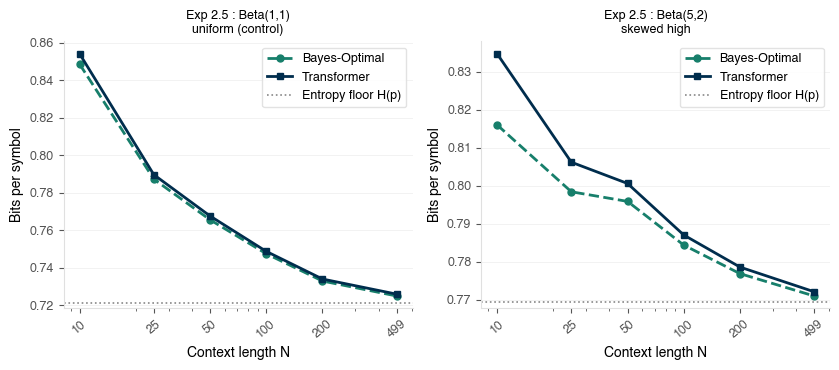

Saved figures/fig3_control_vs_asymmetric


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
fig.patch.set_facecolor(BG)

pairs     = [(1.0,1.0), (5.0,2.0)]
subtitles = ['Control: nothing to learn', 'Asymmetric prior: prior learning visible']

for ax, (alpha, beta), subtitle in zip(axes, pairs, subtitles):
    s  = all_results[(alpha, beta)]
    ns = np.array(N_VALUES)

    for key, color, ls, marker, lbl in [
        ('bayes_optimal', C_BAYES,       '--', 'o', 'Bayes-Optimal'),
        ('transformer',   C_TRANSFORMER, '-',  's', 'Transformer'),
    ]:
        means = np.array([get_mean(s, N, key) for N in N_VALUES])
        stds  = np.array([get_std(s,  N, key) for N in N_VALUES])
        ax.plot(ns, means, color=color, lw=2.0, ls=ls,
                marker=marker, ms=5, label=lbl)
        #ax.fill_between(ns, means - stds, means + stds,
                        #color=color, alpha=0.12)

    ax.axhline(ENTROPY_FLOOR[(alpha, beta)], color=C_ENTROPY,
               lw=1.2, ls=':', label='Entropy floor H(p)')

    ax.set_xscale('log')
    ax.set_xticks(N_VALUES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)
    ax.set_xlabel('Context length N', fontsize=10)
    ax.set_ylabel('Bits per symbol', fontsize=10)
    ax.set_title(f'Exp 2.5 : {PRIOR_LABELS[(alpha,beta)]}', fontsize=9, pad=6)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/fig3_control_vs_asymmetric.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fig3_control_vs_asymmetric.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fig3_control_vs_asymmetric')

## Fig 4: Individual plots per prior

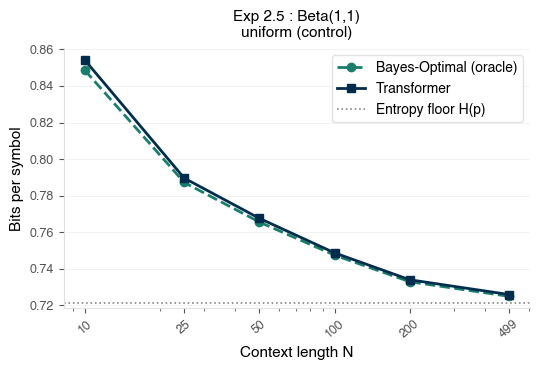

Saved figures/fig4_beta_1p0_1p0


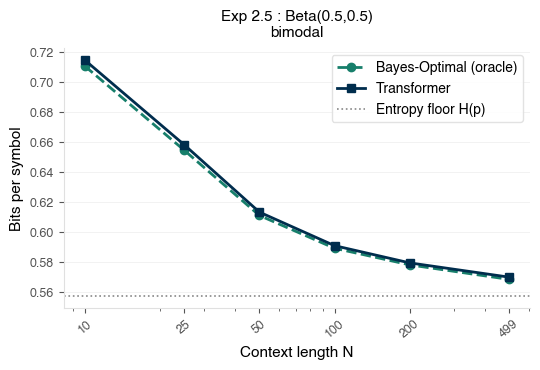

Saved figures/fig4_beta_0p5_0p5


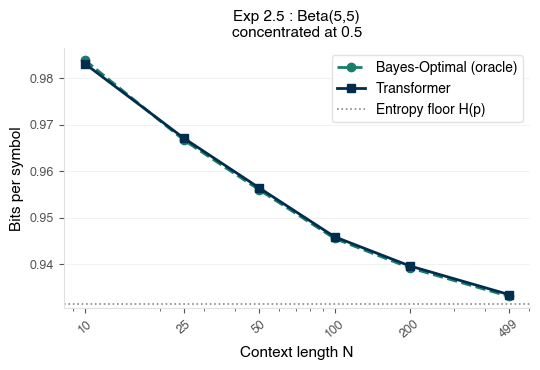

Saved figures/fig4_beta_5p0_5p0


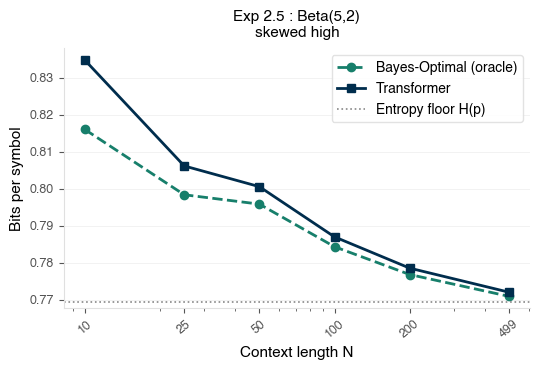

Saved figures/fig4_beta_5p0_2p0


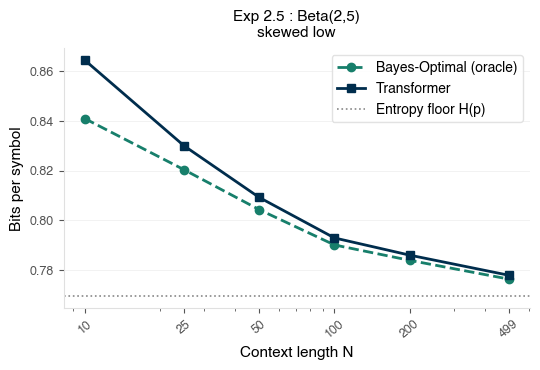

Saved figures/fig4_beta_2p0_5p0


In [ ]:

from scipy.stats import norm
Z = norm.ppf(0.975)

for alpha, beta in PRIORS:
    s  = all_results[(alpha, beta)]
    ns = np.array(N_VALUES)
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    fig.patch.set_facecolor(BG)

    for key, color, ls, marker, lbl in [
        ('bayes_optimal', C_BAYES,       '--', 'o', 'Bayes-Optimal (oracle)'),
        ('transformer',   C_TRANSFORMER, '-',  's', 'Transformer'),
    ]:
        means = np.array([get_mean(s, N, key) for N in N_VALUES])
        stds  = np.array([get_std(s,  N, key) for N in N_VALUES])
        ci    = Z * stds / np.sqrt(500)   # NUM_TEST

        ax.plot(ns, means, color=color, lw=2.0, ls=ls,
                marker=marker, ms=6, label=lbl)

    ax.axhline(ENTROPY_FLOOR[(alpha, beta)], color=C_ENTROPY,
               lw=1.2, ls=':', label='Entropy floor H(p)')

    ax.set_xscale('log')
    ax.set_xticks(N_VALUES)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)
    ax.set_xlabel('Context length N', fontsize=11)
    ax.set_ylabel('Bits per symbol', fontsize=11)
    ax.set_title(f'Exp 2.5 : {PRIOR_LABELS[(alpha, beta)]}', fontsize=11, fontweight='bold', pad=8)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    slug = f'beta_{str(alpha).replace(".","p")}_{str(beta).replace(".","p")}'
    plt.tight_layout()
    plt.savefig(f'figures/fig4_{slug}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/fig4_{slug}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/fig4_{slug}')

## Gap summary table

In [ ]:
print(f'{"Prior":<26} {"Xfmr-BO (N=10)":>16} {"CTW-BO (N=10)":>15} '
      f'{"Xfmr-BO (N=499)":>17} {"CTW-BO (N=499)":>16}')
print('-' * 92)
for alpha, beta in PRIORS:
    s   = all_results[(alpha, beta)]
    lbl = f'Beta({alpha},{beta})'
    x10  = get_mean(s, 10,  'transformer') - get_mean(s, 10,  'bayes_optimal')
    c10  = get_mean(s, 10,  'ctw')         - get_mean(s, 10,  'bayes_optimal')
    x499 = get_mean(s, 499, 'transformer') - get_mean(s, 499, 'bayes_optimal')
    c499 = get_mean(s, 499, 'ctw')         - get_mean(s, 499, 'bayes_optimal')
    print(f'{lbl:<26} {x10:>16.4f} {c10:>15.4f} {x499:>17.4f} {c499:>16.4f}')

Prior                        Xfmr-BO (N=10)   CTW-BO (N=10)   Xfmr-BO (N=499)   CTW-BO (N=499)
--------------------------------------------------------------------------------------------
Beta(1.0,1.0)                        0.0056          0.1374            0.0010           0.0066
Beta(0.5,0.5)                        0.0040          0.2672            0.0015           0.0086
Beta(5.0,5.0)                       -0.0008          0.0198            0.0004           0.0053
Beta(5.0,2.0)                        0.0187          0.1732            0.0011           0.0078
Beta(2.0,5.0)                        0.0235          0.1498            0.0015           0.0074
